In [1]:
import os
from pathlib import Path

_cwd = Path.cwd()
if _cwd.name != 'notebooks':
    _nb_dir = _cwd / 'notebooks'
    if _nb_dir.is_dir():
        os.chdir(_nb_dir)

for _d in ['../outputs', '../data', '../models']:
    Path(_d).mkdir(exist_ok=True)

print(f'cwd: {Path.cwd()}')

cwd: c:\Users\adria\OneDrive\Desktop\Proyecto de machine learning\notebooks


# Fase 5 — Entrenamiento del Modelo ML (v2)

Versión mejorada en tres frentes:

### Frente 1 — Balanceo de clases
El dataset tiene **58 BAJA vs 28 SUBE**. En v1, el modelo predijo SUBE solo 14 veces de 86 con 21% de win rate. Solución:
- **scale_pos_weight = n_neg/n_pos ≈ 2.07**: penaliza al modelo 2x más por cada error en la clase SUBE
- **GridSearch optimizando F1** en lugar de accuracy: la métrica correcta con clases desbalanceadas
- **SMOTE en LR**: para la regresión logística que no tiene scale_pos_weight nativo

### Frente 2 — Mejores features (sin ticker dummies)
Las 11 ticker dummies consumían la mitad de features con solo 86 filas → overfitting. Las reemplazamos por 4 features con más señal:
- `eps_surprise_abs`: magnitud del EPS surprise (captura shocks grandes)
- `momentum_vol_ratio`: momentum normalizado por la volatilidad del período
- `finbert_confidence`: certeza de FinBERT (máx entre score positivo y negativo)
- `sent_momentum_align`: si el sentimiento del texto y el precio van en la misma dirección

### Frente 3 — Umbral óptimo via sweep de backtesting
El umbral de 0.50 por defecto no es óptimo. Barremos umbrales [0.30, 0.85] y elegimos
el que maximiza el capital final en la estrategia long-only, balanceando win rate vs cantidad de apuestas.

## 1. Importar librerías

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import VotingClassifier
from sklearn.model_selection import (
    StratifiedKFold, cross_validate, cross_val_predict,
    train_test_split, RandomizedSearchCV
)
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve, average_precision_score
)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from scipy.stats import randint, uniform

print('Librerías cargadas correctamente')

Librerías cargadas correctamente


## 2. Cargar datos y construir features mejoradas (FRENTE 2)

Eliminamos las 11 ticker dummies y agregamos 4 features derivadas con mayor poder predictivo.

In [3]:
df = pd.read_csv('../data/features.csv')

# Features derivadas inline (complementan las que ya vienen del notebook 04)
df['eps_surprise_abs']    = df['eps_surprise_pct'].abs()
df['momentum_vol_ratio']  = df['momentum_5d'] / (df['volatility_20d'] + 0.01)
df['finbert_confidence']  = df[['score_positivo', 'score_negativo']].max(axis=1)
df['sent_momentum_align'] = (np.sign(df['polaridad']) == np.sign(df['momentum_5d'])).astype(int)

feature_cols = [
    # EPS (señal dominante)
    'eps_surprise_pct', 'eps_surprise_abs', 'eps_surprise_trend', 'eps_surprise_zscore',
    # Precio
    'momentum_5d', 'momentum_20d', 'volatility_20d', 'momentum_vol_ratio', 'momentum_agreement',
    # FinBERT
    'score_positivo', 'score_negativo', 'score_neutral', 'polaridad', 'finbert_confidence',
    # Keywords
    'kw_positivos', 'kw_negativos', 'kw_ratio', 'kw_cat_enc',
    # NLP del texto crudo (nuevas)
    'uncertainty_score', 'forward_guidance_score', 'text_length_log',
    'question_density', 'negative_words_score',
    # Interacciones
    'sent_momentum_align', 'tiene_transcripcion',
]

# Usamos DataFrame para que LightGBM no tire warnings de feature names
X = df[feature_cols]
y = df['target'].values

n_neg = (y == 0).sum()
n_pos = (y == 1).sum()
scale_pos_weight = round(n_neg / n_pos, 3)

print(f'X shape: {X.shape}  →  {X.shape[0]} muestras × {X.shape[1]} features')
print(f'Distribución: BAJA={n_neg}, SUBE={n_pos}')
print(f'scale_pos_weight = {n_neg}/{n_pos} = {scale_pos_weight}')
print(f'\nFeatures ({len(feature_cols)}): {feature_cols}')

X shape: (228, 25)  →  228 muestras × 25 features
Distribución: BAJA=139, SUBE=89
scale_pos_weight = 139/89 = 1.562

Features (25): ['eps_surprise_pct', 'eps_surprise_abs', 'eps_surprise_trend', 'eps_surprise_zscore', 'momentum_5d', 'momentum_20d', 'volatility_20d', 'momentum_vol_ratio', 'momentum_agreement', 'score_positivo', 'score_negativo', 'score_neutral', 'polaridad', 'finbert_confidence', 'kw_positivos', 'kw_negativos', 'kw_ratio', 'kw_cat_enc', 'uncertainty_score', 'forward_guidance_score', 'text_length_log', 'question_density', 'negative_words_score', 'sent_momentum_align', 'tiene_transcripcion']


## 3. Validación cruzada con balanceo (FRENTE 1)

**XGBoost**: usa `scale_pos_weight` directamente (no necesita SMOTE).
Esto penaliza los errores en la clase minoritaria sin cambiar los datos.

**LR**: usa `SMOTE` dentro del pipeline CV + `class_weight='balanced'`.
El `ImbPipeline` garantiza que SMOTE se aplique solo al training fold — sin data leakage.

Optimizamos **F1** en el GridSearch: es la métrica correcta cuando las clases no están balanceadas.

In [4]:
cv    = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
smote = SMOTE(random_state=42, k_neighbors=3)
scoring = ['accuracy', 'precision', 'recall', 'f1']

# LR con SMOTE + class_weight balanced
pipe_lr = ImbPipeline([
    ('smote',  smote),
    ('scaler', StandardScaler()),
    ('model',  LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'))
])

# XGBoost con scale_pos_weight
xgb_base = XGBClassifier(
    n_estimators=200, max_depth=3, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42, eval_metric='logloss', verbosity=0
)

# LightGBM con scale_pos_weight
lgbm_base = LGBMClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    random_state=42, verbose=-1
)

print('Evaluando LR (SMOTE + class_weight=balanced)...')
cv_lr = cross_validate(pipe_lr, X, y, cv=cv, scoring=scoring)

print('Evaluando XGBoost (scale_pos_weight)...')
cv_xgb = cross_validate(xgb_base, X, y, cv=cv, scoring=scoring)

print('Evaluando LightGBM (scale_pos_weight)...')
cv_lgbm = cross_validate(lgbm_base, X, y, cv=cv, scoring=scoring)

print('Done.')

Evaluando LR (SMOTE + class_weight=balanced)...
Evaluando XGBoost (scale_pos_weight)...
Evaluando LightGBM (scale_pos_weight)...
Done.


## 4. Resultados CV — v1 vs v2

In [5]:
def resumen_cv(cv_result, nombre):
    return {
        'Modelo':    nombre,
        'Accuracy':  f"{cv_result['test_accuracy'].mean():.3f} ± {cv_result['test_accuracy'].std():.3f}",
        'Precision': f"{cv_result['test_precision'].mean():.3f} ± {cv_result['test_precision'].std():.3f}",
        'Recall':    f"{cv_result['test_recall'].mean():.3f} ± {cv_result['test_recall'].std():.3f}",
        'F1':        f"{cv_result['test_f1'].mean():.3f} ± {cv_result['test_f1'].std():.3f}",
        '_f1_mean':  cv_result['test_f1'].mean(),
    }

filas = [
    resumen_cv(cv_lr,   'LR       (SMOTE + balanced)'),
    resumen_cv(cv_xgb,  'XGBoost  (scale_pos_weight)'),
    resumen_cv(cv_lgbm, 'LightGBM (scale_pos_weight)'),
]

tabla = pd.DataFrame(filas).set_index('Modelo').drop(columns=['_f1_mean'])
print('=== CV 5-fold v3 ===')
print(tabla.to_string())
print()
print('Referencias v1 (sin balanceo, con ticker dummies):')
print('  LR : F1=0.279   XGB: F1=0.140')
print('Referencias v2 (XGBoost + 16 features + target 1d):')
print('  LR : F1=0.392   XGB: F1=0.382')

best_base = max(filas, key=lambda r: r['_f1_mean'])
print(f'\nMejor modelo base: {best_base["Modelo"].strip()}  F1={best_base["_f1_mean"]:.3f}')

=== CV 5-fold v3 ===
                                  Accuracy      Precision         Recall             F1
Modelo                                                                                 
LR       (SMOTE + balanced)  0.561 ± 0.079  0.411 ± 0.142  0.425 ± 0.195  0.413 ± 0.169
XGBoost  (scale_pos_weight)  0.606 ± 0.043  0.494 ± 0.055  0.529 ± 0.112  0.507 ± 0.075
LightGBM (scale_pos_weight)  0.562 ± 0.044  0.441 ± 0.064  0.495 ± 0.125  0.462 ± 0.086

Referencias v1 (sin balanceo, con ticker dummies):
  LR : F1=0.279   XGB: F1=0.140
Referencias v2 (XGBoost + 16 features + target 1d):
  LR : F1=0.392   XGB: F1=0.382

Mejor modelo base: XGBoost  (scale_pos_weight)  F1=0.507


## 4b. Ensemble XGBoost + LightGBM

Un voting suave (promedio de probabilidades) suele superar a cualquier modelo individual, especialmente en datasets pequeños donde cada modelo puede capturar patrones distintos.

In [6]:
xgb_ens  = XGBClassifier(n_estimators=200, max_depth=3, learning_rate=0.05,
                          subsample=0.8, colsample_bytree=0.8,
                          scale_pos_weight=scale_pos_weight,
                          random_state=42, eval_metric='logloss', verbosity=0)
lgbm_ens = LGBMClassifier(n_estimators=200, max_depth=4, learning_rate=0.05,
                           scale_pos_weight=scale_pos_weight,
                           random_state=42, verbose=-1)

ensemble = VotingClassifier(
    estimators=[('xgb', xgb_ens), ('lgbm', lgbm_ens)],
    voting='soft', weights=[1, 1]
)

print('Evaluando Ensemble XGBoost + LightGBM (soft voting)...')
cv_ens = cross_validate(ensemble, X, y, cv=cv, scoring=scoring)

ens_f1 = cv_ens['test_f1'].mean()
print(f'Ensemble F1: {ens_f1:.3f} ± {cv_ens["test_f1"].std():.3f}')
print(f'Ensemble Precision: {cv_ens["test_precision"].mean():.3f}')
print(f'Ensemble Recall: {cv_ens["test_recall"].mean():.3f}')

mejora = ens_f1 - max(cv_lgbm['test_f1'].mean(), cv_xgb['test_f1'].mean())
print(f'\nMejora del ensemble vs mejor modelo individual: {mejora:+.3f}')

Evaluando Ensemble XGBoost + LightGBM (soft voting)...
Ensemble F1: 0.489 ± 0.097
Ensemble Precision: 0.470
Ensemble Recall: 0.518

Mejora del ensemble vs mejor modelo individual: -0.018


## 5. Optimización de hiperparámetros (GridSearch con F1)

Optimizamos **F1** — no accuracy. Con clases desbalanceadas, un modelo que dice
BAJA siempre tiene accuracy de 67% pero F1=0. El GridSearch con F1 fuerza al
modelo a aprender a identificar la clase SUBE.

In [7]:
param_dist = {
    'n_estimators':     randint(50, 300),
    'max_depth':        randint(2, 5),
    'learning_rate':    uniform(0.01, 0.2),
    'subsample':        uniform(0.6, 0.4),
    'min_child_weight': randint(2, 10),
    'gamma':            uniform(0, 0.5),
    'colsample_bytree': uniform(0.5, 0.5),
}

xgb_search = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    random_state=42, eval_metric='logloss', verbosity=0
)

search = RandomizedSearchCV(
    xgb_search, param_dist,
    n_iter=80, cv=cv,
    scoring='f1',   # <-- clave: optimizamos F1, no accuracy
    random_state=42, n_jobs=-1
)
search.fit(X, y)

best_params = search.best_params_
print(f'Mejor F1 CV: {search.best_score_:.3f}  (v1 optimizaba accuracy: 0.580)')
print('Mejores parámetros:')
for k, v in best_params.items():
    print(f'  {k}: {v}')

Mejor F1 CV: 0.535  (v1 optimizaba accuracy: 0.580)
Mejores parámetros:
  colsample_bytree: 0.5226520048860223
  gamma: 0.1873063073132356
  learning_rate: 0.13517198314284729
  max_depth: 3
  min_child_weight: 9
  n_estimators: 50
  subsample: 0.815750979360025


## 6. Evaluación final — train/test split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)

# LR con SMOTE solo en train
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)
scaler = StandardScaler()
lr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr.fit(scaler.fit_transform(X_train_sm), y_train_sm)
y_pred_lr = lr.predict(scaler.transform(X_test))

# XGBoost con mejores params + scale_pos_weight
xgb = XGBClassifier(
    **best_params, scale_pos_weight=scale_pos_weight,
    random_state=42, eval_metric='logloss', verbosity=0
)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

print(f'Train: {X_train.shape[0]}  |  Test: {X_test.shape[0]}')
print()
for nombre, y_pred in [('LR ', y_pred_lr), ('XGB', y_pred_xgb)]:
    print(f'{nombre} — Acc={accuracy_score(y_test, y_pred):.3f}  '
          f'Prec={precision_score(y_test, y_pred, zero_division=0):.3f}  '
          f'Rec={recall_score(y_test, y_pred, zero_division=0):.3f}  '
          f'F1={f1_score(y_test, y_pred, zero_division=0):.3f}')

Train: 159  |  Test: 69

LR  — Acc=0.478  Prec=0.304  Rec=0.259  F1=0.280
XGB — Acc=0.609  Prec=0.500  Rec=0.593  F1=0.542


## 7. Matrices de confusión

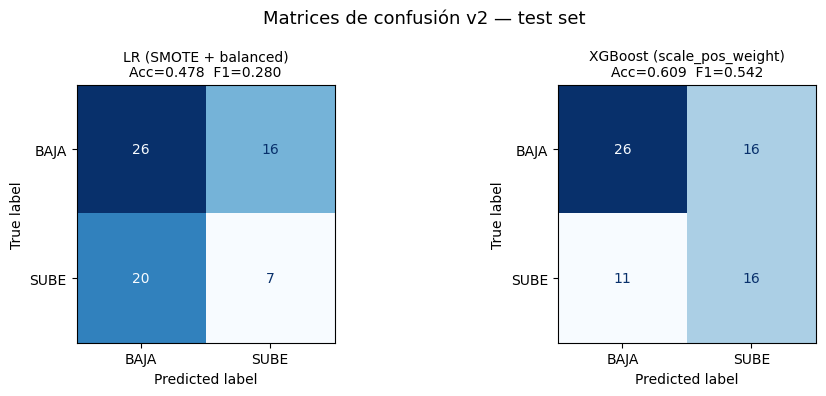

Guardado en outputs/confusion_matrices.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, y_pred, titulo in zip(
    axes,
    [y_pred_lr, y_pred_xgb],
    ['LR (SMOTE + balanced)', 'XGBoost (scale_pos_weight)']
):
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['BAJA', 'SUBE']).plot(
        ax=ax, colorbar=False, cmap='Blues'
    )
    ax.set_title(
        f'{titulo}\n'
        f'Acc={accuracy_score(y_test, y_pred):.3f}  '
        f'F1={f1_score(y_test, y_pred, zero_division=0):.3f}',
        fontsize=10
    )

plt.suptitle('Matrices de confusión v2 — test set', fontsize=13)
plt.tight_layout()
plt.savefig('../outputs/confusion_matrices.png', dpi=120, bbox_inches='tight')
plt.show()
print('Guardado en outputs/confusion_matrices.png')

## 8. Umbral óptimo via curva Precision-Recall + sweep (FRENTE 3)

El umbral por defecto (0.50) no es el óptimo. Analizamos dos enfoques:

1. **Curva PR**: muestra el trade-off precision vs recall en todos los umbrales posibles.
2. **Sweep de backtesting**: barremos umbrales [0.30, 0.85] y elegimos el que maximiza
   el capital final en la estrategia long-only — más directo para el objetivo de trading.

Usamos predicciones **OOS** (cross_val_predict) para que el sweep no esté sobreajustado al train.

In [10]:
# Usamos el ensemble como modelo final
modelo_final = ensemble
modelo_final.fit(X, y)  # fit completo (X ya es DataFrame, sin warnings)

# Probabilidades OOS con el ensemble — sin data leakage
print('Generando probabilidades OOS del ensemble...')
prob_oos = cross_val_predict(ensemble, X, y, cv=cv, method='predict_proba')[:, 1]

# Curva Precision-Recall
prec, rec, thresholds = precision_recall_curve(y, prob_oos)
ap = average_precision_score(y, prob_oos)
print(f'AP score ensemble: {ap:.3f}  (baseline = {n_pos/len(y):.3f})')

# Sweep usando retorno_5d (aligned con el target)
capital_inicial = 10_000
order    = df['fecha_earnings'].argsort().values
prob_ord = prob_oos[order]
ret5_ord = df.iloc[order]['retorno_5d'].values
tgt_ord  = y[order]

# Buy & Hold con retorno 5d
bnh_cap = capital_inicial
for r in ret5_ord:
    bnh_cap *= (1 + r / 100)

sweep_rows = []
best_cap = 0; best_u = 0.5
for u in np.arange(0.30, 0.86, 0.05):
    mask = prob_ord >= u
    if mask.sum() < 3:
        break
    cap = capital_inicial
    for p, r in zip(prob_ord, ret5_ord):
        if p >= u:
            cap *= (1 + r / 100)
    wr = tgt_ord[mask].mean()
    sweep_rows.append({
        'Umbral': round(u, 2), 'N apuestas': int(mask.sum()),
        'Win rate': round(wr, 3), 'Capital': round(cap, 0),
        'Retorno %': round((cap / capital_inicial - 1) * 100, 1)
    })
    if cap > best_cap:
        best_cap = cap; best_u = round(u, 2)
        best_n   = int(mask.sum()); best_wr = wr

best_threshold = best_u
df_sweep = pd.DataFrame(sweep_rows)

print(f'\nBuy & Hold (retorno 5d): ${bnh_cap:,.0f}  ({(bnh_cap/capital_inicial-1)*100:+.1f}%)')
print(f'\n=== Sweep de umbrales (Long-only, retorno 5d) ===')
print(df_sweep.to_string(index=False))
print(f'\nUmbral óptimo: {best_threshold}  →  {best_n} apuestas, win={best_wr:.1%}, capital=${best_cap:,.0f}')

Generando probabilidades OOS del ensemble...
AP score ensemble: 0.493  (baseline = 0.390)

Buy & Hold (retorno 5d): $89,368  (+793.7%)

=== Sweep de umbrales (Long-only, retorno 5d) ===
 Umbral  N apuestas  Win rate  Capital  Retorno %
   0.30         154     0.442  53986.0      439.9
   0.35         143     0.441  50137.0      401.4
   0.40         128     0.469  71575.0      615.8
   0.45         114     0.447  41204.0      312.0
   0.50          97     0.474  52120.0      421.2
   0.55          88     0.489  52149.0      421.5
   0.60          76     0.487  49051.0      390.5
   0.65          57     0.491  32804.0      228.0
   0.70          45     0.556  32111.0      221.1
   0.75          37     0.568  36122.0      261.2
   0.80          21     0.619  28650.0      186.5
   0.85          14     0.714  19284.0       92.8

Umbral óptimo: 0.4  →  128 apuestas, win=46.9%, capital=$71,575


## 9. Gráfico — Curva Precision-Recall

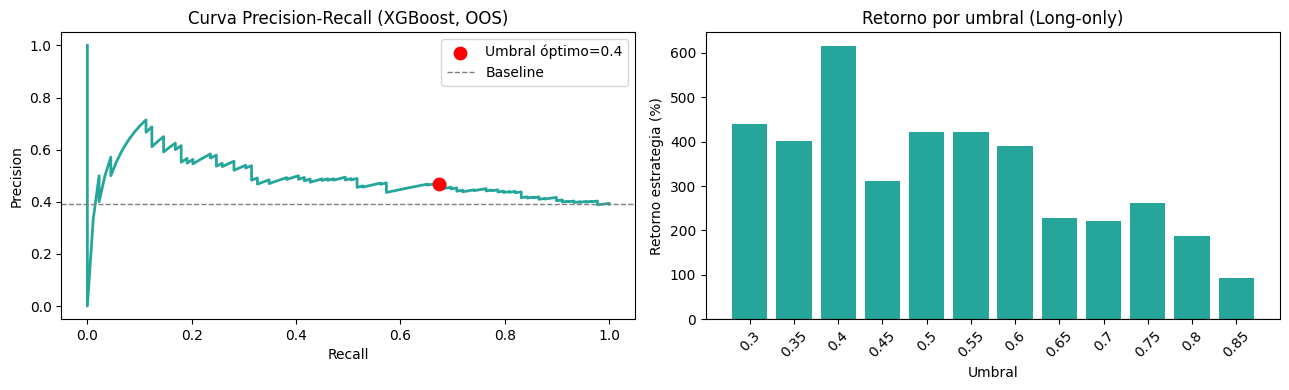

Guardado en outputs/precision_recall_curve.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# PR curve
ax = axes[0]
ax.plot(rec, prec, color='#26a69a', linewidth=2)
# Marcar el umbral óptimo del sweep
prec_u = prec[np.argmin(np.abs(thresholds - best_threshold))] if len(thresholds) > 0 else 0
rec_u  = rec[np.argmin(np.abs(thresholds - best_threshold))]  if len(thresholds) > 0 else 0
ax.scatter(rec_u, prec_u, color='red', zorder=5, s=80,
           label=f'Umbral óptimo={best_threshold}')
ax.axhline(n_pos/len(y), color='gray', linestyle='--', linewidth=1, label='Baseline')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Curva Precision-Recall (XGBoost, OOS)')
ax.legend()

# Retorno vs umbral
ax = axes[1]
df_sweep_plot = df_sweep.copy()
colors = ['#ef5350' if r < 0 else '#26a69a' for r in df_sweep_plot['Retorno %']]
ax.bar(df_sweep_plot['Umbral'].astype(str), df_sweep_plot['Retorno %'], color=colors)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel('Umbral')
ax.set_ylabel('Retorno estrategia (%)')
ax.set_title('Retorno por umbral (Long-only)')
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../outputs/precision_recall_curve.png', dpi=120, bbox_inches='tight')
plt.show()
print('Guardado en outputs/precision_recall_curve.png')

## 10. Feature Importance — ¿qué features dominan ahora?

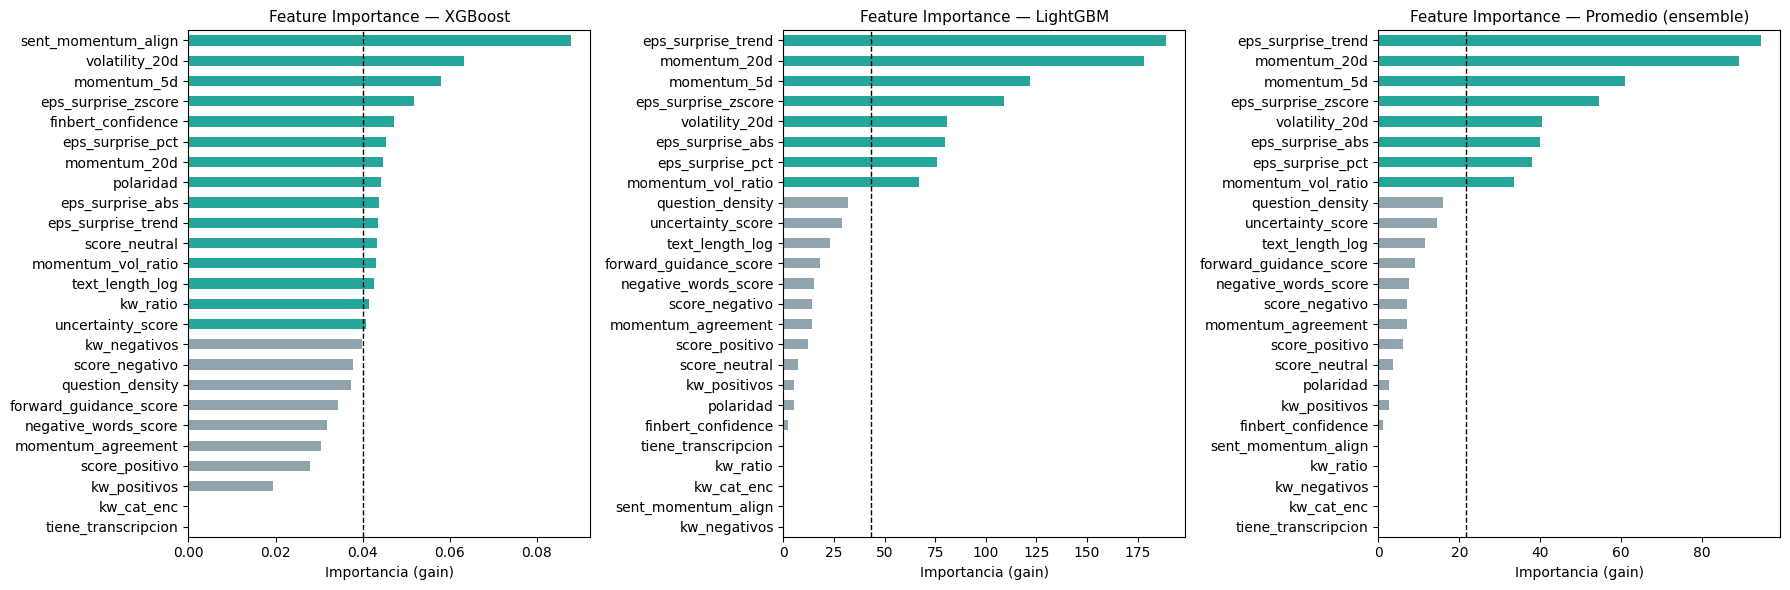

Guardado en outputs/feature_importance.png

Top 5 features (promedio ensemble):
eps_surprise_trend     94.5218
momentum_20d           89.0223
momentum_5d            61.0291
eps_surprise_zscore    54.5259
volatility_20d         40.5317
dtype: float64


In [12]:
# El ensemble ya está fitteado desde la celda anterior (modelo_final.fit)
xgb_fitted  = ensemble.estimators_[0]   # XGBoost
lgbm_fitted = ensemble.estimators_[1]   # LightGBM

imp_xgb  = pd.Series(xgb_fitted.feature_importances_,  index=feature_cols)
imp_lgbm = pd.Series(lgbm_fitted.feature_importances_, index=feature_cols)
imp_avg  = (imp_xgb + imp_lgbm) / 2

imp_sorted = imp_avg.sort_values(ascending=True)
colors = ['#26a69a' if v >= imp_avg.mean() else '#90a4ae' for v in imp_sorted]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, imp, titulo in zip(
    axes,
    [imp_xgb.sort_values(ascending=True),
     imp_lgbm.sort_values(ascending=True),
     imp_sorted],
    ['XGBoost', 'LightGBM', 'Promedio (ensemble)']
):
    c = ['#26a69a' if v >= imp.mean() else '#90a4ae' for v in imp]
    imp.plot(kind='barh', ax=ax, color=c)
    ax.axvline(imp.mean(), color='black', linewidth=1, linestyle='--')
    ax.set_title(f'Feature Importance — {titulo}', fontsize=11)
    ax.set_xlabel('Importancia (gain)')

plt.tight_layout()
plt.savefig('../outputs/feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()
print('Guardado en outputs/feature_importance.png')
print('\nTop 5 features (promedio ensemble):')
print(imp_avg.sort_values(ascending=False).head(5).round(4))

## 11. Guardar modelo final

In [13]:
modelo_info = {
    'model':            ensemble,
    'feature_cols':     feature_cols,
    'best_threshold':   best_threshold,
    'scale_pos_weight': scale_pos_weight,
    'cv_f1_xgb':        round(cv_xgb['test_f1'].mean(), 4),
    'cv_f1_lgbm':       round(cv_lgbm['test_f1'].mean(), 4),
    'cv_f1_ensemble':   round(cv_ens['test_f1'].mean(), 4),
    'prob_oos':         prob_oos,
}

joblib.dump(modelo_info, '../models/xgboost_model.pkl')

check = joblib.load('../models/xgboost_model.pkl')
print('Modelo guardado en models/xgboost_model.pkl')
print(f'  Modelo:              Ensemble (XGBoost + LightGBM, soft voting)')
print(f'  CV F1 XGBoost:       {check["cv_f1_xgb"]}')
print(f'  CV F1 LightGBM:      {check["cv_f1_lgbm"]}')
print(f'  CV F1 Ensemble:      {check["cv_f1_ensemble"]}')
print(f'  Umbral óptimo:       {check["best_threshold"]}')
print(f'  scale_pos_weight:    {check["scale_pos_weight"]}')
print(f'  Features ({len(check["feature_cols"])}):     {check["feature_cols"]}')

Modelo guardado en models/xgboost_model.pkl
  Modelo:              Ensemble (XGBoost + LightGBM, soft voting)
  CV F1 XGBoost:       0.5066
  CV F1 LightGBM:      0.462
  CV F1 Ensemble:      0.4888
  Umbral óptimo:       0.4
  scale_pos_weight:    1.562
  Features (25):     ['eps_surprise_pct', 'eps_surprise_abs', 'eps_surprise_trend', 'eps_surprise_zscore', 'momentum_5d', 'momentum_20d', 'volatility_20d', 'momentum_vol_ratio', 'momentum_agreement', 'score_positivo', 'score_negativo', 'score_neutral', 'polaridad', 'finbert_confidence', 'kw_positivos', 'kw_negativos', 'kw_ratio', 'kw_cat_enc', 'uncertainty_score', 'forward_guidance_score', 'text_length_log', 'question_density', 'negative_words_score', 'sent_momentum_align', 'tiene_transcripcion']
